# Avocado Price - Model Building

### 1. Import & Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,StackingRegressor
from sklearn.neighbors import KNeighborsRegressor

import sys
sys.path.append('.')
from utils import *

sns.set_style('whitegrid')
plt.rcParams['figure.figsize']= (10,6)

%matplotlib inline

In [3]:
df= load_data('data\\avocado_cleaned.csv')
print(df.shape)
df.head()

(18249, 74)


,AveragePrice,total_volume,small_hass,large_hass,xl_hass,total_bags,small_bags,large_bags,xl_bags,year,...,region_SouthCarolina,region_SouthCentral,region_Southeast,region_Spokane,region_StLouis,region_Syracuse,region_Tampa,region_TotalUS,region_West,region_WestTexNewMexico
0,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,2015,...,0,0,0,0,0,0,0,0,0,0
1,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,2015,...,0,0,0,0,0,0,0,0,0,0
2,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,2015,...,0,0,0,0,0,0,0,0,0,0
3,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,2015,...,0,0,0,0,0,0,0,0,0,0
4,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,2015,...,0,0,0,0,0,0,0,0,0,0


### 2. Train / Test Split 

In [4]:
X = df.drop(columns='AveragePrice')
y= df['AveragePrice']

X_train,X_test, y_train,y_test= train_test_split(X ,y, test_size=0.2, random_state=42)

print(f"X-Train size: {X_train.shape}, X-Test size: {X_test.shape}")
print(f"Train mean price = {y_train.mean():.2f} \n Test Mean Price = {y_test.mean():.2f}")

X-Train size: (14599, 73), X-Test size: (3650, 73)
Train mean price = 1.40 
 Test Mean Price = 1.41


# Models

In [5]:
models = {
    'Linear Regressor' : Pipeline([('scaler', StandardScaler()),
                    ('model', LinearRegression())]),
    
    'Ridge' : Pipeline([('scaler', StandardScaler()),
                    ('model', Ridge(alpha= 1.0, random_state=42))]),
    
    'Lasso' : Pipeline([('scaler', StandardScaler()),
                        ('model', Lasso(alpha =0.001, random_state=42, max_iter=20000))]),
    
    'Decision Tree' : Pipeline([
                                ('model', DecisionTreeRegressor(max_depth=10, random_state=42))]),
    
    'Random Forest' : Pipeline([
                                ('model', RandomForestRegressor(n_estimators= 200, random_state=42, n_jobs = -1))]),
    
    'Gradient Boosting' : Pipeline([
                                ('model', GradientBoostingRegressor(random_state=42, n_estimators =200))]),
    
    'KNN' : Pipeline([('scaler', StandardScaler()),
                        ('model', KNeighborsRegressor(n_neighbors=4, n_jobs= -1))]),
}


     Linear Regressor
    RMSE: 0.2169
    R2: 0.7072
    MAE: 0.1623
    MAPE: 0.1188


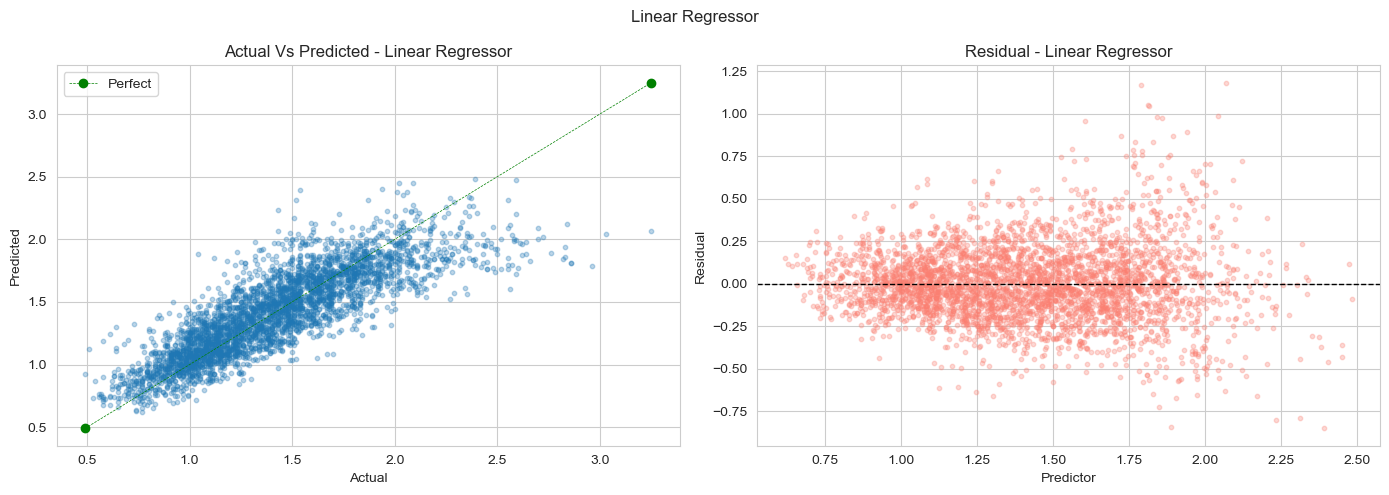


     Ridge
    RMSE: 0.2168
    R2: 0.7074
    MAE: 0.1622
    MAPE: 0.1188


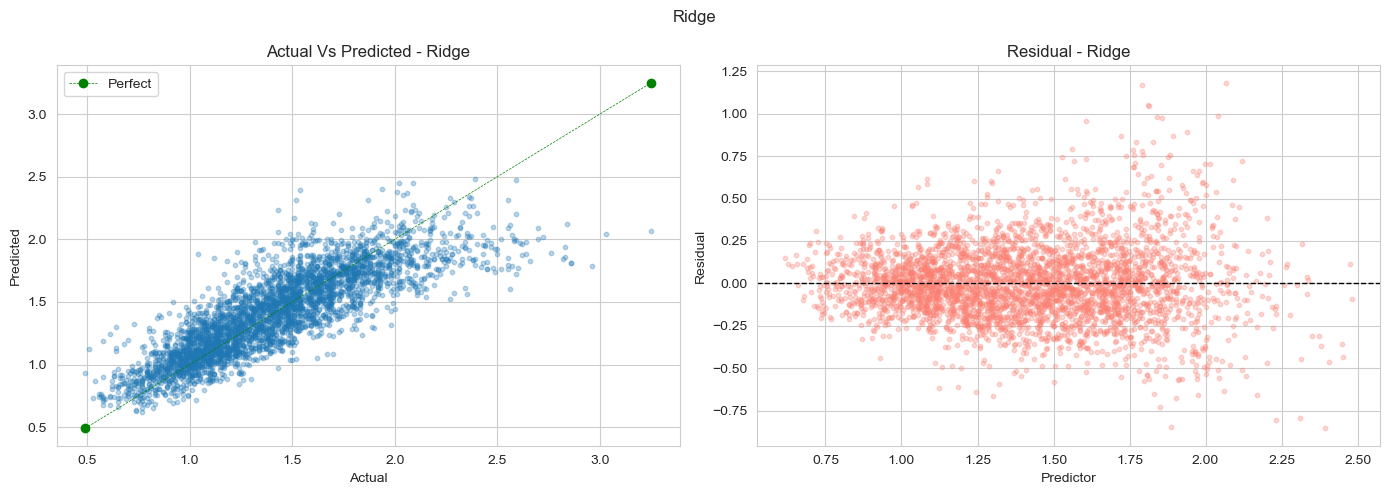


     Lasso
    RMSE: 0.2209
    R2: 0.6964
    MAE: 0.1649
    MAPE: 0.1214


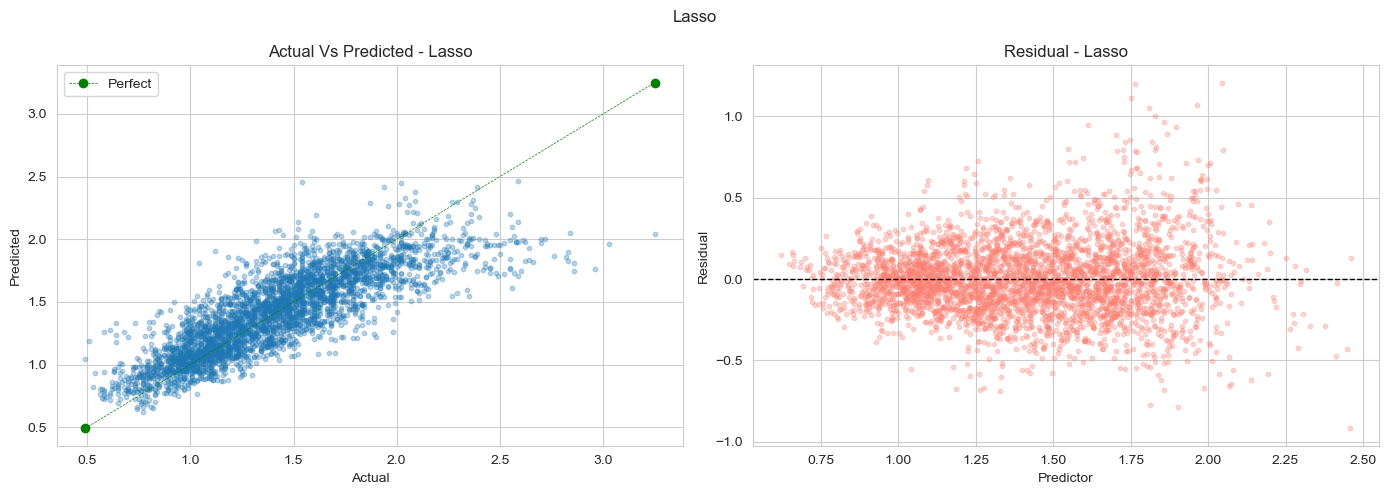


     Decision Tree
    RMSE: 0.1990
    R2: 0.7534
    MAE: 0.1430
    MAPE: 0.1037


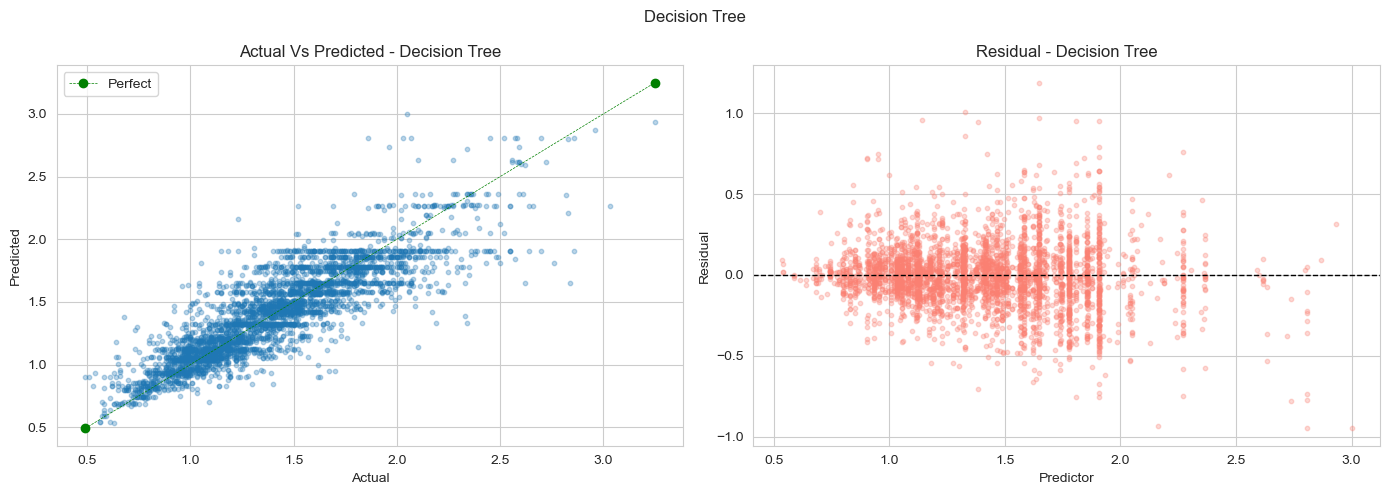


     Random Forest
    RMSE: 0.1212
    R2: 0.9086
    MAE: 0.0856
    MAPE: 0.0637


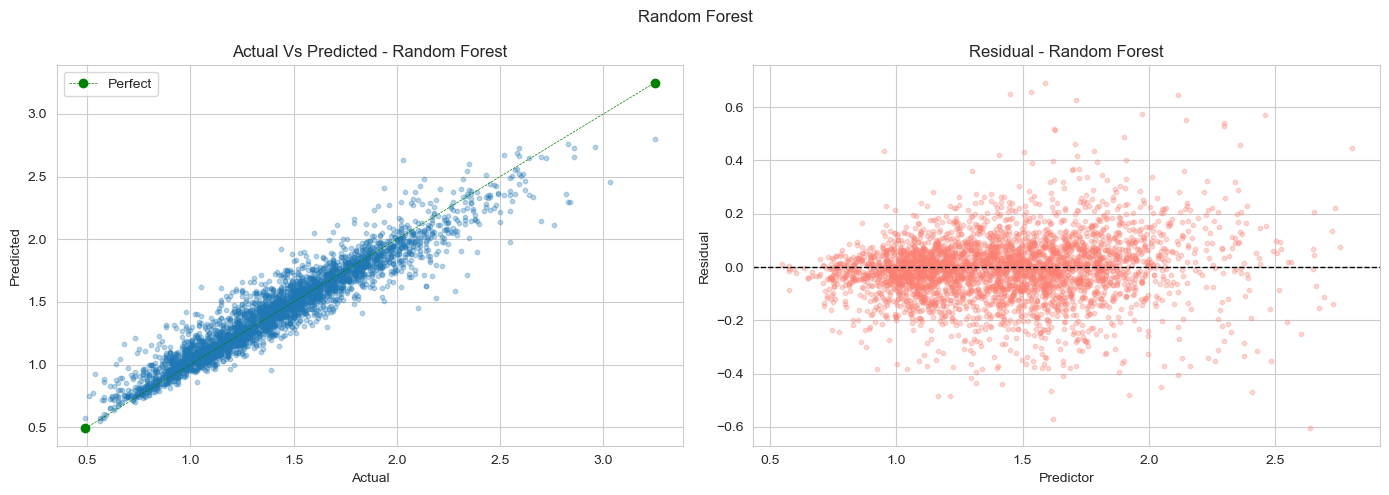


     Gradient Boosting
    RMSE: 0.1800
    R2: 0.7984
    MAE: 0.1353
    MAPE: 0.1000


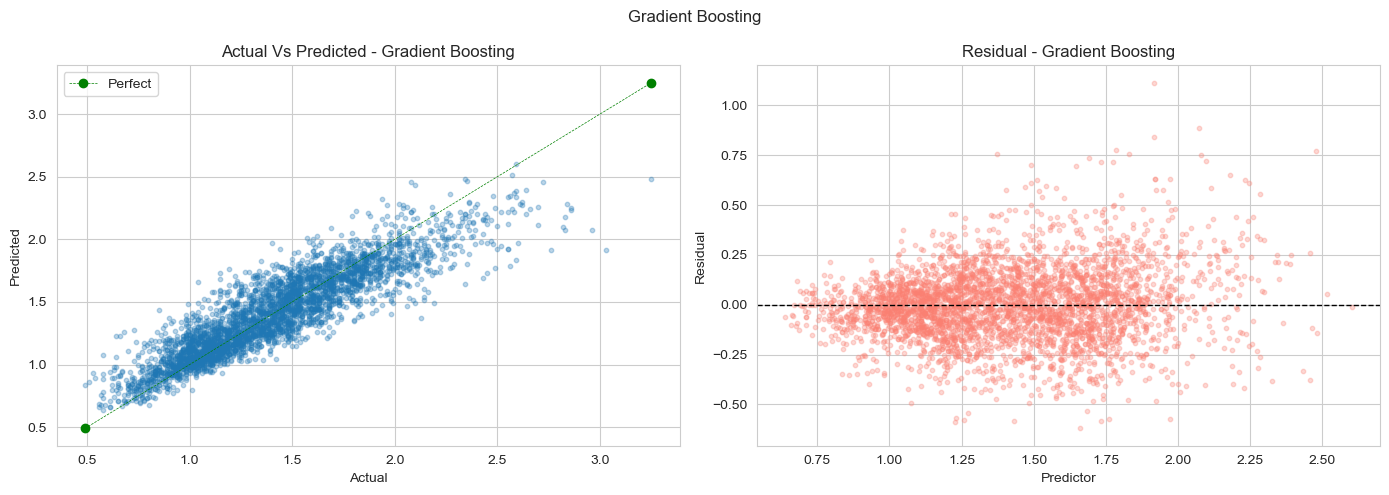


     KNN
    RMSE: 0.1358
    R2: 0.8853
    MAE: 0.0949
    MAPE: 0.0712


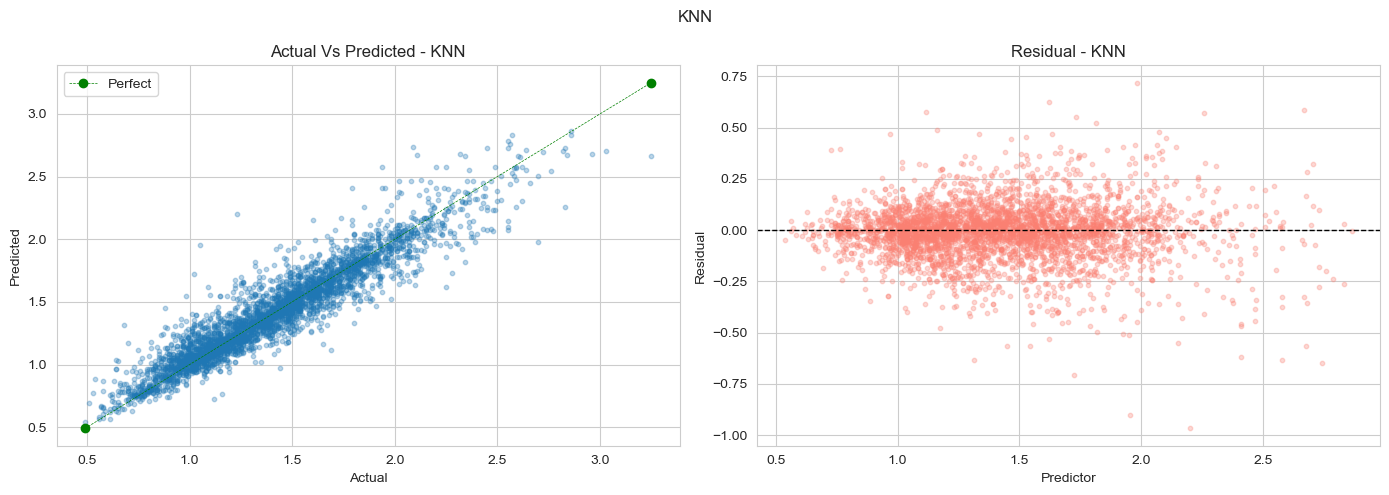

In [6]:
metric_store = []

for model_name , estimators in models.items():
    
    estimators.fit(X_train, y_train)
    est_pred = estimators.predict(X_test)
    
    est_metric = metric(y_test, est_pred, model_name)
    metric_store.append(est_metric)
    
    fig, axes = plt.subplots(1,2, figsize =(14, 5))
    
    plot_a_vs_pred(y_test, est_pred, model_name, ax= axes[0])
    plot_residual(y_test, est_pred, model_name, ax= axes[1])
    plt.suptitle(model_name, fontweight= 50)
    
    plt.tight_layout(); plt.show()

### Tunning KNN model

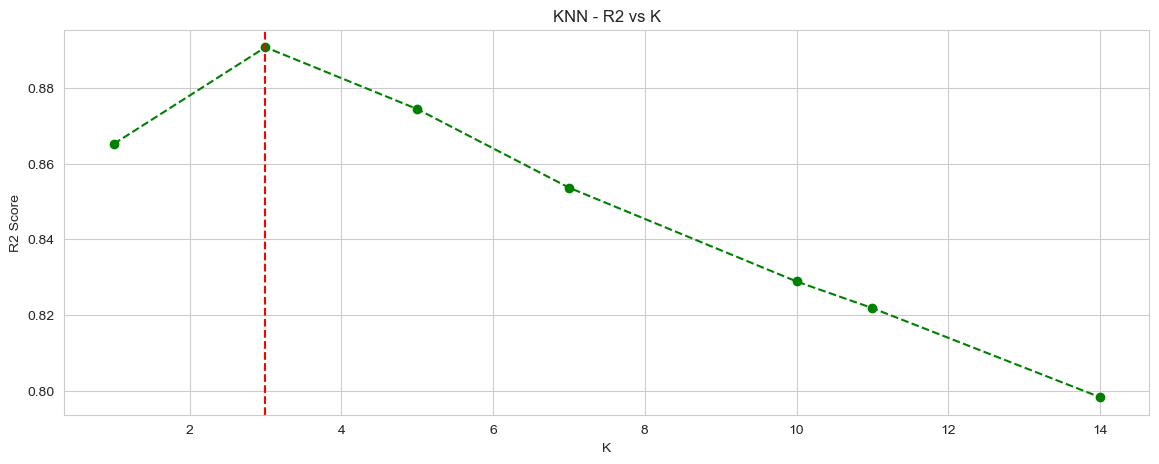

In [7]:
k_num = [1,3, 5, 7, 10, 11,14]
scores = []
for k in k_num:
    knn_pipe = Pipeline([('scaler', StandardScaler()),
                        ('knn', KNeighborsRegressor(n_neighbors=k, n_jobs= -1))])
    knn_pipe.fit(X_train, y_train)
    
    knn_ppred = knn_pipe.predict(X_test)
    score = r2_score(y_test, knn_ppred)
    scores.append(score)

best_k = k_num[np.argmax(scores)]

fig, ax = plt.subplots(figsize= (14, 5))
ax.plot(k_num , scores, color= 'green', marker='o', linestyle='--')
ax.axvline(best_k, color = 'red', linestyle='--', label= f'Best K-{best_k}')
ax.set_xlabel("K");     ax.set_ylabel('R2 Score');  ax.set_title("KNN - R2 vs K")
plt.show()


     Optimized KNN
    RMSE: 0.1325
    R2: 0.8907
    MAE: 0.0915
    MAPE: 0.0687


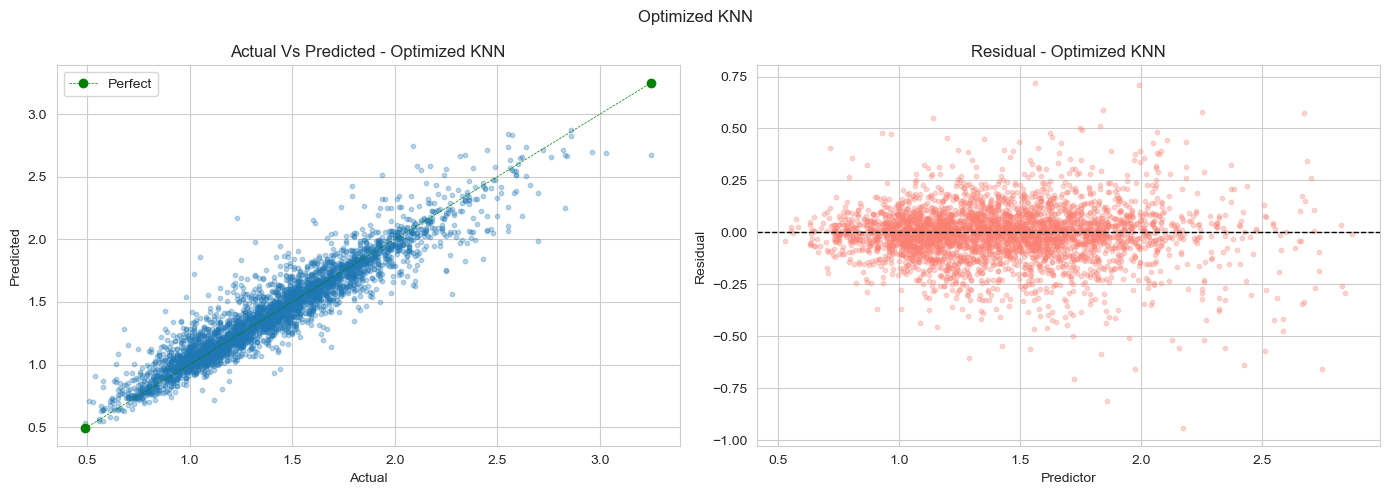

In [8]:
r_knn = Pipeline([('scaler', StandardScaler()),
                    ('knn', KNeighborsRegressor(n_neighbors=best_k, n_jobs= -1))])
r_knn.fit(X_train, y_train)

knn_pred = r_knn.predict(X_test)

knn_metric = metric(y_test, knn_pred, "Optimized KNN")
metric_store.append(knn_metric)

fig, axes = plt.subplots(1,2 , figsize =(14, 5))
plot_a_vs_pred(y_test, knn_pred, "Optimized KNN", ax=axes[0])
plot_residual(y_test, knn_pred, "Optimized KNN", ax=axes[1])
plt.suptitle("Optimized KNN", fontweight= 50)

plt.tight_layout();     plt.show()

## Feature Importance 

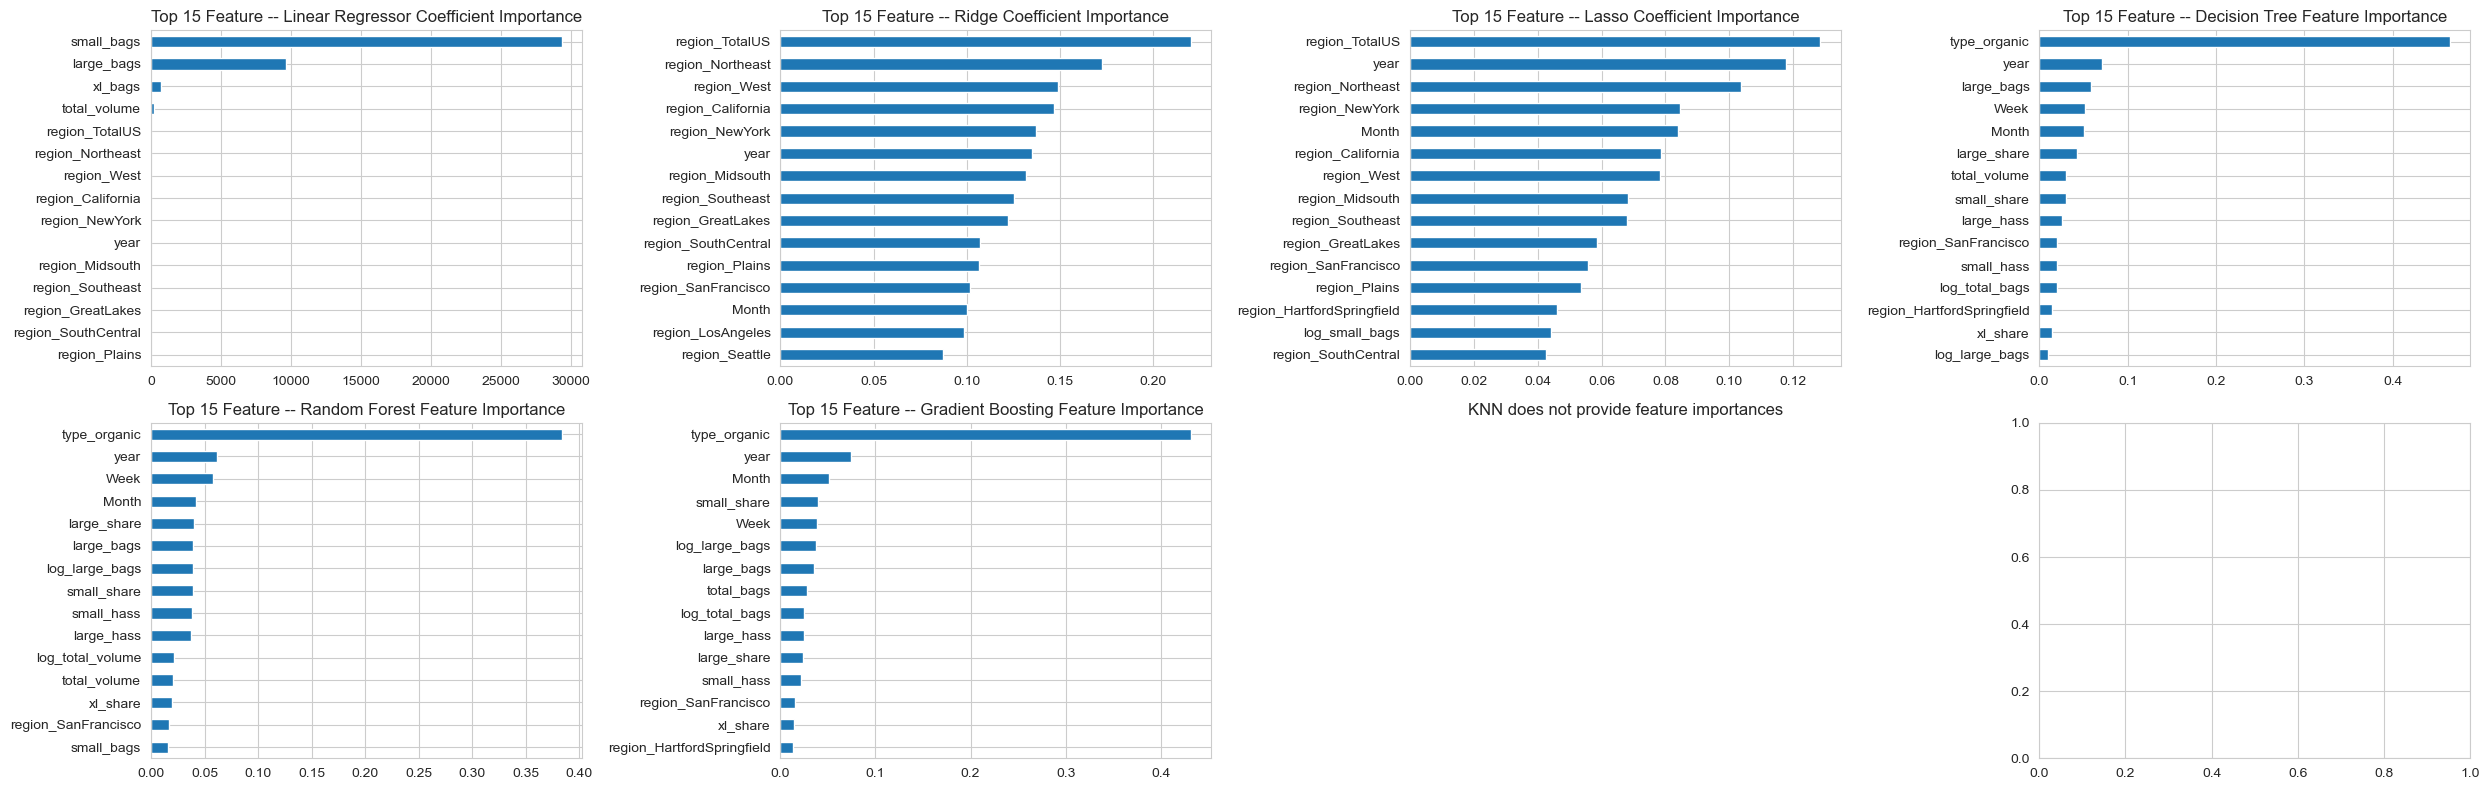

In [9]:
fig, axes = plt.subplots(2,4, figsize= (25,8))
axes =axes.flatten()   # Flatten the axes array for easy iteration

for i, (model_name, model) in enumerate(models.items()):
    ax = axes[i]
    #est = model.steps[-1][1]  # Get the last step of the pipeline which is the model itself
    est = model.named_steps['model']  # Access the model from the pipeline
    
    if hasattr(est, 'feature_importances_'):
        imp = pd.Series(est.feature_importances_, index= X_train.columns).sort_values()
        imp.tail(15).plot(kind='barh', ax= ax)
        ax.set_title(f"Top 15 Feature -- {model_name} Feature Importance")
        
    elif hasattr(est, 'coef_'):
        imp = pd.Series(est.coef_, index=X_train.columns).sort_values()
        imp.tail(15).plot(kind='barh', ax=ax)
        ax.set_title(f"Top 15 Feature -- {model_name} Coefficient Importance")  
    
    else:
        ax.axis('off')  # Turn off the axis if the model doesn't have feature importances or coefficients
        ax.set_title(f"{model_name} does not provide feature importances")
    

plt.tight_layout(); plt.show()

## Model Comparism

In [10]:
results_df = pd.DataFrame(metric_store).sort_values(by='R2', ascending= False).reset_index(drop=True)

results_df.round(4)

results_df.style.background_gradient(cmap='viridis_r', subset=['R2', 'RMSE', 'MAE','MAPE'], axis=0)

,Model,RMSE,R2,MAE,MAPE
0,Random Forest,0.121208,0.908562,0.085619,0.063683
1,Optimized KNN,0.132540,0.890664,0.091480,0.068699
2,KNN,0.135773,0.885265,0.094894,0.071249
3,Gradient Boosting,0.179980,0.798388,0.135340,0.100010
4,Decision Tree,0.199048,0.753404,0.142978,0.103691
5,Ridge,0.216830,0.707380,0.162225,0.118771
6,Linear Regressor,0.216888,0.707222,0.162273,0.118797
7,Lasso,0.220855,0.696415,0.164855,0.121357


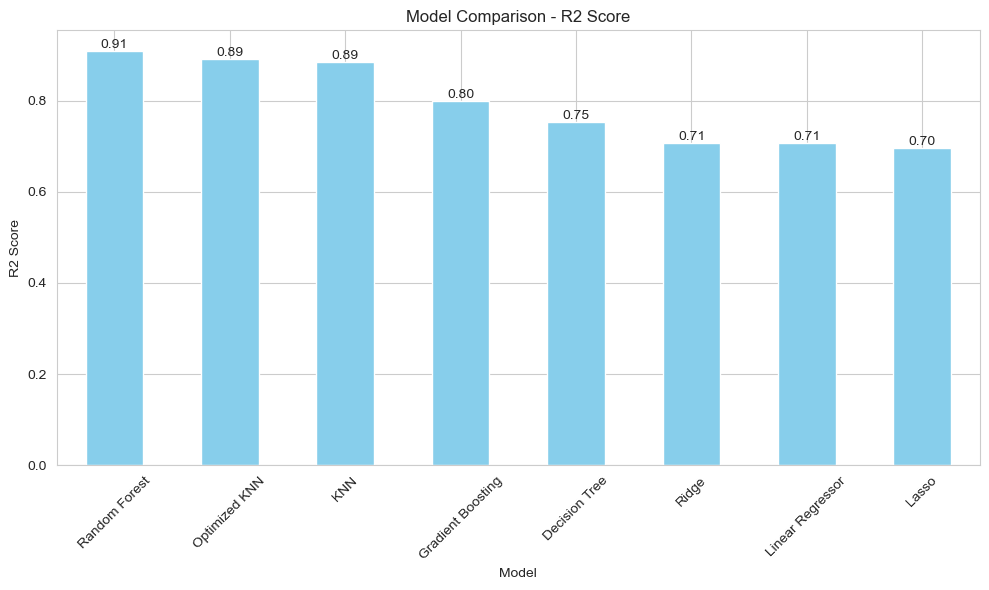

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

results_df['R2'].plot(kind='bar', ax=ax, color='skyblue',)

for i ,v in enumerate(results_df['R2']):
    ax.text(i, v, f'{v:.2f}', ha='center', va='bottom')
ax.set_xlabel('Model');     ax.set_ylabel('R2 Score');     ax.set_title('Model Comparison - R2 Score')

ax.set_xticklabels(results_df['Model'], rotation= 45)
plt.tight_layout(); plt.show()

## 5-Fold Cross Validation

In [12]:
cv_models = models.copy()

cv_results = {}
for model_name , estimators in cv_models.items():
    print(f"Cross Validation for {model_name}")
    score = cross_val_score(estimators, X_train, y_train, cv=5, scoring='r2')
    
    cv_results[model_name] = score
    
    print(f"    R2 Score: {score.round(4)}")
    print(f"    Mean    : {score.mean():.4f} | Std: (+/- {score.std():.4f})\n")
    
    
    

Cross Validation for Linear Regressor
    R2 Score: [0.7094 0.7118 0.7172 0.6958 0.6972]
    Mean    : 0.7063 | Std: (+/- 0.0084)

Cross Validation for Ridge
    R2 Score: [0.7096 0.7118 0.717  0.6958 0.6972]
    Mean    : 0.7063 | Std: (+/- 0.0083)

Cross Validation for Lasso
    R2 Score: [0.6993 0.7038 0.7068 0.685  0.6848]
    Mean    : 0.6959 | Std: (+/- 0.0093)

Cross Validation for Decision Tree
    R2 Score: [0.7353 0.7415 0.7514 0.7386 0.7376]
    Mean    : 0.7409 | Std: (+/- 0.0056)

Cross Validation for Random Forest
    R2 Score: [0.8966 0.8923 0.9023 0.8945 0.8902]
    Mean    : 0.8952 | Std: (+/- 0.0042)

Cross Validation for Gradient Boosting
    R2 Score: [0.7985 0.7912 0.8027 0.796  0.792 ]
    Mean    : 0.7961 | Std: (+/- 0.0043)

Cross Validation for KNN
    R2 Score: [0.8683 0.8656 0.8737 0.8509 0.8555]
    Mean    : 0.8628 | Std: (+/- 0.0084)



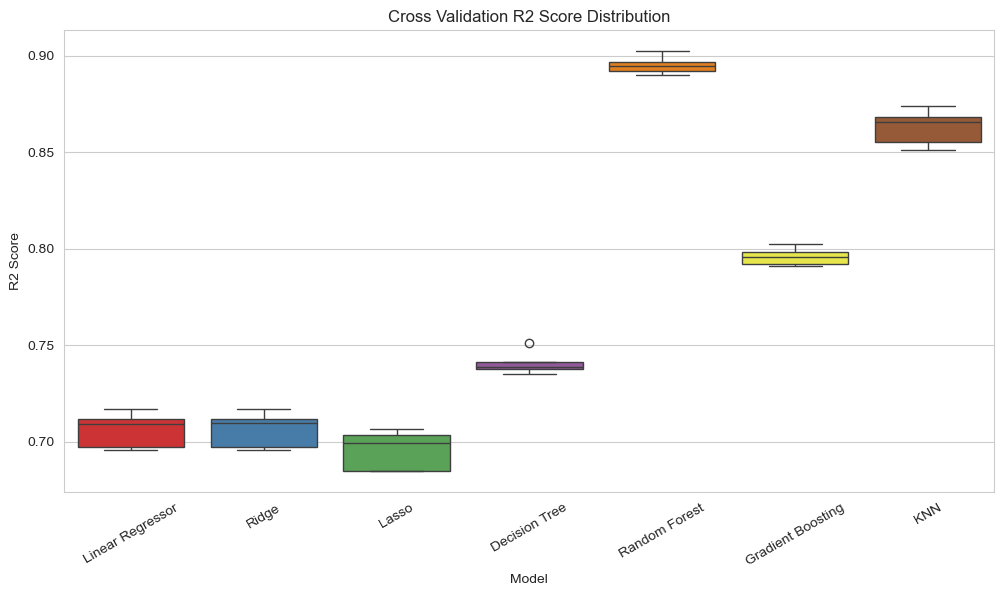

In [13]:
cv_df= pd.DataFrame(cv_results)
plt.figure(figsize=(12, 6))
sns.boxplot(data=cv_df, palette='Set1')
plt.title("Cross Validation R2 Score Distribution")
plt.xticks(rotation= 30);   plt.ylabel("R2 Score"); plt.xlabel("Model")

plt.show()

## Hyperparameter Tuning - Random Forest (grid search)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Best R2 Score: 0.8857

     Optimized Random Forest
    RMSE: 0.1212
    R2: 0.9086
    MAE: 0.0856
    MAPE: 0.0637


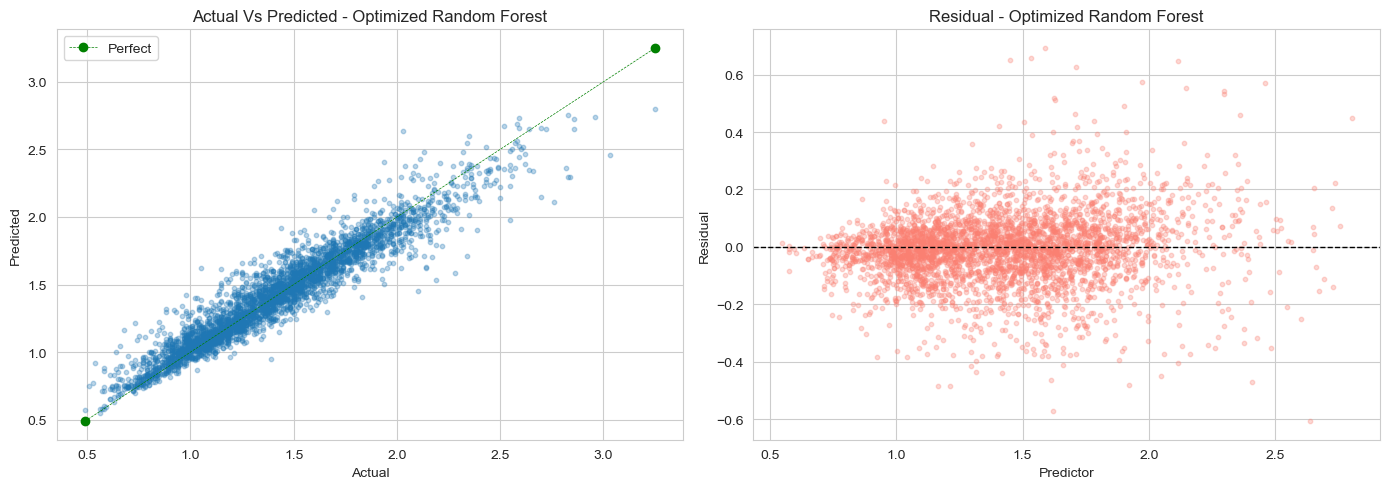

In [16]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 15, 20],
    'min_samples_leaf': [1, 2],
}

rf_grid =GridSearchCV(
    estimator= RandomForestRegressor(random_state=42, n_jobs=1),
    param_grid= param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=3
)

rf_grid.fit(X_train, y_train)

print(f"Best Parameters: {rf_grid.best_params_}")
print(f"Best R2 Score: {rf_grid.best_score_:.4f}")


# Fit the best model from the grid search

rf_best = rf_grid.best_estimator_       # The Best Estimator from the Grid Search

rf_best_pred = rf_best.predict(X_test)

metric_store.append(metric(y_test, rf_best_pred, "Optimized Random Forest"))
fig, axes = plt.subplots(1,2, figsize =(14, 5))
plot_a_vs_pred(y_test, rf_best_pred, "Optimized Random Forest", ax= axes[0])
plot_residual(y_test, rf_best_pred, "Optimized Random Forest", ax= axes[1])

plt.tight_layout(); plt.show()